Model Performance Metrics:
Root Mean Square Error (RMSE): 0.074
R-squared (R2): 0.637
Nash-Sutcliffe Efficiency (NSE): 0.637


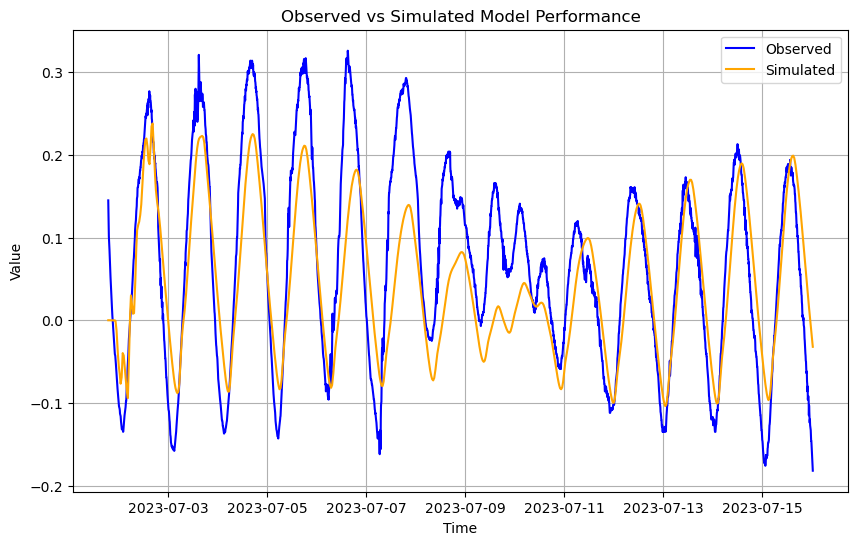

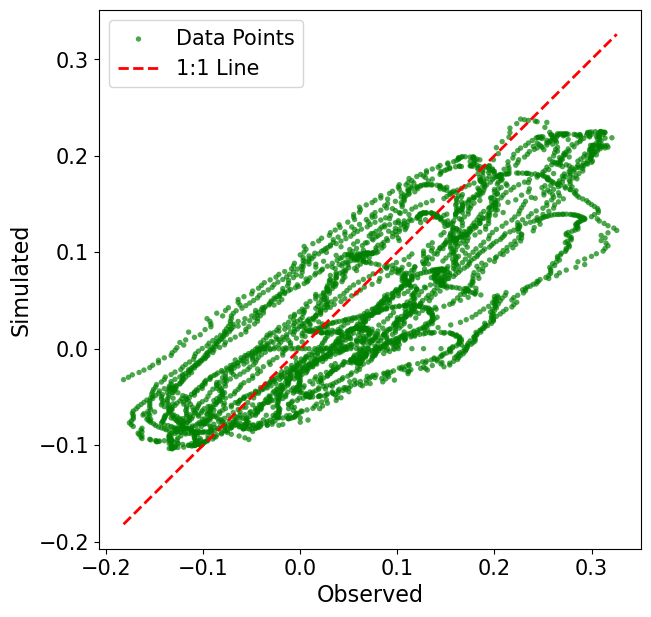

In [24]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Define paths to the observed and simulated dfs0 files
file1 = r"D:\Phd Research\Prototype HD Model\Measured WL\Port Lavaca Jul 2023.dfs0"
file2 = r"D:\Phd Research\Prototype HD Model\Simulation\test_run_July_2023.m21fm - Result Files\Simulated_Matagorda.dfs0"

# Define the time range for filtering
start_time = datetime(2023, 7, 1, 19, 0, 0)
end_time = datetime(2023, 7, 16, 0, 30, 0)

# Read the dfs0 files
observed_dfs = mikeio.read(file1)
simulated_dfs = mikeio.read(file2)

# Extract data and time
observed_time = observed_dfs.time
simulated_time = simulated_dfs.time
observed_data = observed_dfs[0].to_numpy()
simulated_data = simulated_dfs[0].to_numpy()

# Apply time range filtering
observed_mask = (observed_time >= start_time) & (observed_time <= end_time)
simulated_mask = (simulated_time >= start_time) & (simulated_time <= end_time)

observed_time = observed_time[observed_mask]
observed_data = observed_data[observed_mask]
simulated_time = simulated_time[simulated_mask]
simulated_data = simulated_data[simulated_mask]

# Align data by interpolating if time lengths differ
if len(observed_time) != len(simulated_time):
    if len(observed_time) > len(simulated_time):
        # Interpolate simulated data to observed time
        simulated_data = np.interp(
            [t.timestamp() for t in observed_time], 
            [t.timestamp() for t in simulated_time], 
            simulated_data
        )
        time_common = observed_time
    else:
        # Interpolate observed data to simulated time
        observed_data = np.interp(
            [t.timestamp() for t in simulated_time], 
            [t.timestamp() for t in observed_time], 
            observed_data
        )
        time_common = simulated_time
else:
    time_common = observed_time  # No interpolation needed

# Calculate RMSE, R-squared, and NSE without sklearn
rmse = np.sqrt(np.mean((observed_data - simulated_data) ** 2))

# R-squared calculation
ss_res = np.sum((observed_data - simulated_data) ** 2)
ss_tot = np.sum((observed_data - np.mean(observed_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# NSE calculation
nse = 1 - (np.sum((observed_data - simulated_data) ** 2) / np.sum((observed_data - np.mean(observed_data)) ** 2))

print("Model Performance Metrics:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")
print(f"Nash-Sutcliffe Efficiency (NSE): {nse:.3f}")

# Plot observed vs simulated data
plt.figure(figsize=(10, 6))
plt.plot(time_common, observed_data, label="Observed", color="blue")
plt.plot(time_common, simulated_data, label="Simulated", color="orange")

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Observed vs Simulated Model Performance")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Scatter plot of observed vs simulated with a 1:1 line
# Scatter plot of observed vs simulated with a 1:1 line
plt.figure(figsize=(7, 7))

# Customize scatter plot with point size, shape, and color
plt.scatter(
    observed_data, 
    simulated_data, 
    s=15,              # Point size
    c="green",         # Color
    edgecolor="none", # Edge color for points
    alpha=0.7,         # Transparency
    marker="o",        # Point shape ('o' for circles, '^' for triangles, 's' for squares, etc.)
    label="Data Points"
)

# 1:1 line for reference
plt.plot(
    [min(observed_data), max(observed_data)], 
    [min(observed_data), max(observed_data)], 
    'r--', 
    linewidth=2,    # Line width
    label="1:1 Line"  # Label for legend
)

# Customize axis labels, title, and tick parameters
plt.xlabel("Observed", fontsize=16)  # Axis label size
plt.ylabel("Simulated", fontsize=16) # Axis label size


# Customize axis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Adding legend, grid, and display
plt.legend(fontsize=15)


# Adding labels, title, and limits
plt.xlabel("Observed")
plt.ylabel("Simulated")
# plt.title("Observed vs Simulated (1:1 Line)")
plt.grid(False)

# Show the scatter plot
plt.show()


Model Performance Metrics:
Root Mean Square Error (RMSE): 0.402
R-squared (R2): 0.538
Nash-Sutcliffe Efficiency (NSE): 0.538


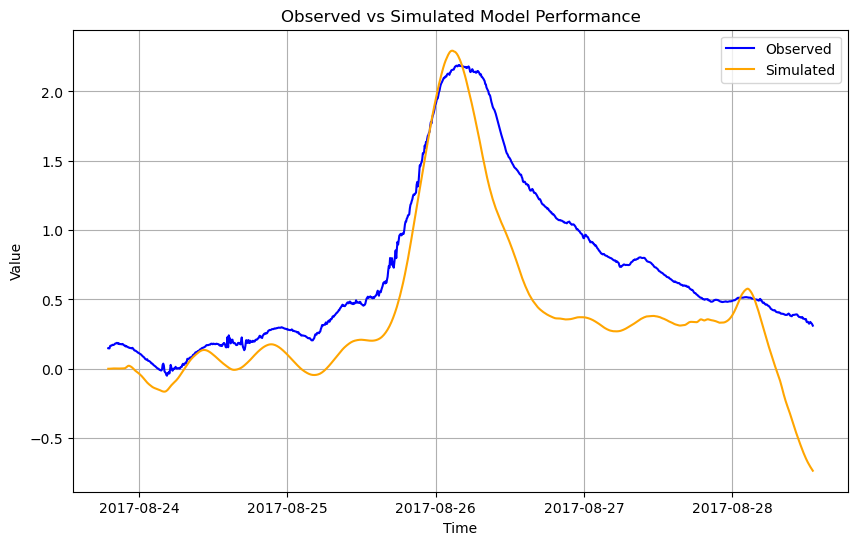

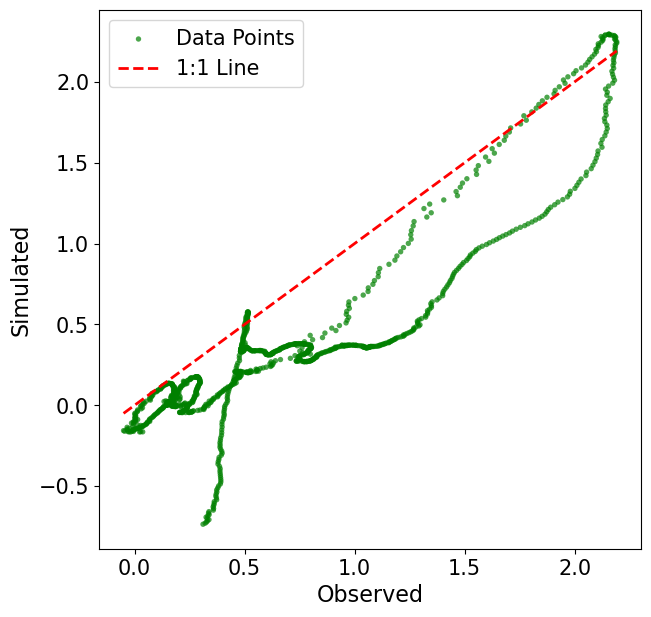

In [23]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Define paths to the observed and simulated dfs0 files
file1 = r"D:\Phd Research\Prototype HD Model\Measured WL\Port Lavaca Aug 2017 Harvey.dfs0"
file2 = r"D:\Phd Research\Prototype HD Model\Simulation\test_run_Hurricane_Harvey.m21fm - Result Files\Simulated port lavaca3.dfs0"

# Define the time range for filtering
start_time = datetime(2017, 8, 23, 19, 0, 0)
end_time = datetime(2017, 8, 28, 13, 0, 0)

# Read the dfs0 files
observed_dfs = mikeio.read(file1)
simulated_dfs = mikeio.read(file2)

# Extract data and time
observed_time = observed_dfs.time
simulated_time = simulated_dfs.time
observed_data = observed_dfs[0].to_numpy()
simulated_data = simulated_dfs[0].to_numpy()

# Apply time range filtering
observed_mask = (observed_time >= start_time) & (observed_time <= end_time)
simulated_mask = (simulated_time >= start_time) & (simulated_time <= end_time)

observed_time = observed_time[observed_mask]
observed_data = observed_data[observed_mask]
simulated_time = simulated_time[simulated_mask]
simulated_data = simulated_data[simulated_mask]

# Align data by interpolating if time lengths differ
if len(observed_time) != len(simulated_time):
    if len(observed_time) > len(simulated_time):
        # Interpolate simulated data to observed time
        simulated_data = np.interp(
            [t.timestamp() for t in observed_time], 
            [t.timestamp() for t in simulated_time], 
            simulated_data
        )
        time_common = observed_time
    else:
        # Interpolate observed data to simulated time
        observed_data = np.interp(
            [t.timestamp() for t in simulated_time], 
            [t.timestamp() for t in observed_time], 
            observed_data
        )
        time_common = simulated_time
else:
    time_common = observed_time  # No interpolation needed

# Calculate RMSE, R-squared, and NSE without sklearn
rmse = np.sqrt(np.mean((observed_data - simulated_data) ** 2))

# R-squared calculation
ss_res = np.sum((observed_data - simulated_data) ** 2)
ss_tot = np.sum((observed_data - np.mean(observed_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# NSE calculation
nse = 1 - (np.sum((observed_data - simulated_data) ** 2) / np.sum((observed_data - np.mean(observed_data)) ** 2))

print("Model Performance Metrics:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")
print(f"Nash-Sutcliffe Efficiency (NSE): {nse:.3f}")

# Plot observed vs simulated data
plt.figure(figsize=(10, 6))
plt.plot(time_common, observed_data, label="Observed", color="blue")
plt.plot(time_common, simulated_data, label="Simulated", color="orange")

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Observed vs Simulated Model Performance")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Scatter plot of observed vs simulated with a 1:1 line
# Scatter plot of observed vs simulated with a 1:1 line
plt.figure(figsize=(7, 7))

# Customize scatter plot with point size, shape, and color
plt.scatter(
    observed_data, 
    simulated_data, 
    s=15,              # Point size
    c="green",         # Color
    edgecolor="none", # Edge color for points
    alpha=0.7,         # Transparency
    marker="o",        # Point shape ('o' for circles, '^' for triangles, 's' for squares, etc.)
    label="Data Points"
)

# 1:1 line for reference
plt.plot(
    [min(observed_data), max(observed_data)], 
    [min(observed_data), max(observed_data)], 
    'r--', 
    linewidth=2,    # Line width
    label="1:1 Line"  # Label for legend
)

# Customize axis labels, title, and tick parameters
plt.xlabel("Observed", fontsize=16)  # Axis label size
plt.ylabel("Simulated", fontsize=16) # Axis label size


# Customize axis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Adding legend, grid, and display
plt.legend(fontsize=15)


# Adding labels, title, and limits
plt.xlabel("Observed")
plt.ylabel("Simulated")
# plt.title("Observed vs Simulated (1:1 Line)")
plt.grid(False)

# Show the scatter plot
plt.show()


Model Performance Metrics:
Root Mean Square Error (RMSE): 0.104
R-squared (R2): 0.134
Nash-Sutcliffe Efficiency (NSE): 0.134


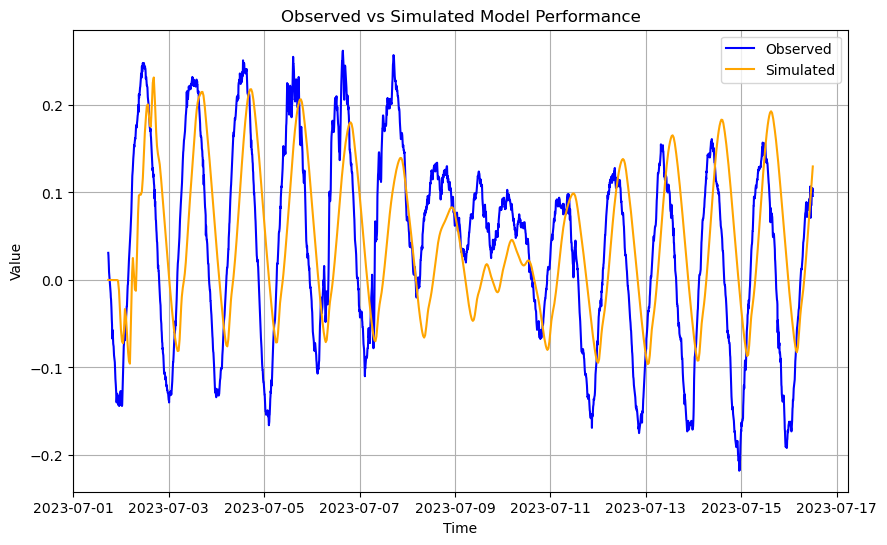

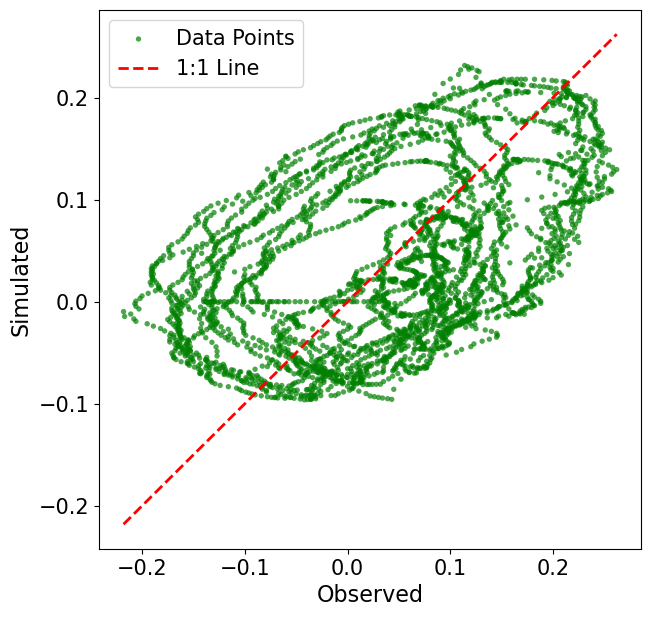

In [21]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Define paths to the observed and simulated dfs0 files
file1 = r"D:\Phd Research\Prototype HD Model\Measured WL\Portocornor JUL 2023.dfs0"
file2 = r"D:\Phd Research\Prototype HD Model\Simulation\test_run_July_2023.m21fm - Result Files\Simulated_Aransas.dfs0"

# Define the time range for filtering
start_time = datetime(2023, 7, 1, 17, 35, 2)
end_time = datetime(2023, 7, 16, 12, 3, 10)

# Read the dfs0 files
observed_dfs = mikeio.read(file1)
simulated_dfs = mikeio.read(file2)

# Extract data and time
observed_time = observed_dfs.time
simulated_time = simulated_dfs.time
observed_data = observed_dfs[0].to_numpy()
simulated_data = simulated_dfs[0].to_numpy()

# Apply time range filtering
observed_mask = (observed_time >= start_time) & (observed_time <= end_time)
simulated_mask = (simulated_time >= start_time) & (simulated_time <= end_time)

observed_time = observed_time[observed_mask]
observed_data = observed_data[observed_mask]
simulated_time = simulated_time[simulated_mask]
simulated_data = simulated_data[simulated_mask]

# Align data by interpolating if time lengths differ
if len(observed_time) != len(simulated_time):
    if len(observed_time) > len(simulated_time):
        # Interpolate simulated data to observed time
        simulated_data = np.interp(
            [t.timestamp() for t in observed_time], 
            [t.timestamp() for t in simulated_time], 
            simulated_data
        )
        time_common = observed_time
    else:
        # Interpolate observed data to simulated time
        observed_data = np.interp(
            [t.timestamp() for t in simulated_time], 
            [t.timestamp() for t in observed_time], 
            observed_data
        )
        time_common = simulated_time
else:
    time_common = observed_time  # No interpolation needed

# Calculate RMSE, R-squared, and NSE without sklearn
rmse = np.sqrt(np.mean((observed_data - simulated_data) ** 2))

# R-squared calculation
ss_res = np.sum((observed_data - simulated_data) ** 2)
ss_tot = np.sum((observed_data - np.mean(observed_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# NSE calculation
nse = 1 - (np.sum((observed_data - simulated_data) ** 2) / np.sum((observed_data - np.mean(observed_data)) ** 2))

print("Model Performance Metrics:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")
print(f"Nash-Sutcliffe Efficiency (NSE): {nse:.3f}")

# Plot observed vs simulated data
plt.figure(figsize=(10, 6))
plt.plot(time_common, observed_data, label="Observed", color="blue")
plt.plot(time_common, simulated_data, label="Simulated", color="orange")

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Observed vs Simulated Model Performance")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Scatter plot of observed vs simulated with a 1:1 line
# Scatter plot of observed vs simulated with a 1:1 line
plt.figure(figsize=(7, 7))

# Customize scatter plot with point size, shape, and color
plt.scatter(
    observed_data, 
    simulated_data, 
    s=15,              # Point size
    c="green",         # Color
    edgecolor="none", # Edge color for points
    alpha=0.7,         # Transparency
    marker="o",        # Point shape ('o' for circles, '^' for triangles, 's' for squares, etc.)
    label="Data Points"
)

# 1:1 line for reference
plt.plot(
    [min(observed_data), max(observed_data)], 
    [min(observed_data), max(observed_data)], 
    'r--', 
    linewidth=2,    # Line width
    label="1:1 Line"  # Label for legend
)

# Customize axis labels, title, and tick parameters
plt.xlabel("Observed", fontsize=16)  # Axis label size
plt.ylabel("Simulated", fontsize=16) # Axis label size


# Customize axis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Adding legend, grid, and display
plt.legend(fontsize=15)


# Adding labels, title, and limits
plt.xlabel("Observed")
plt.ylabel("Simulated")
# plt.title("Observed vs Simulated (1:1 Line)")
plt.grid(False)

# Show the scatter plot
plt.show()


Model Performance Metrics:
Root Mean Square Error (RMSE): 0.092
R-squared (R2): 0.157
Nash-Sutcliffe Efficiency (NSE): 0.157


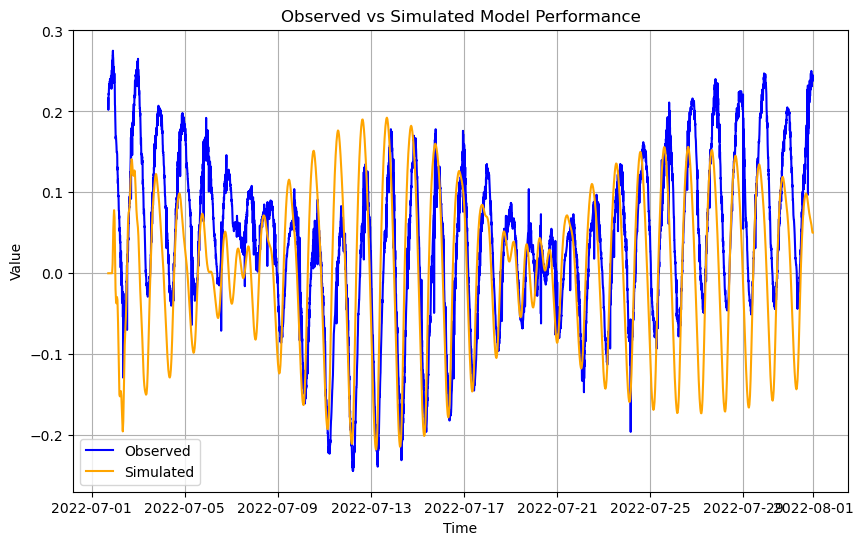

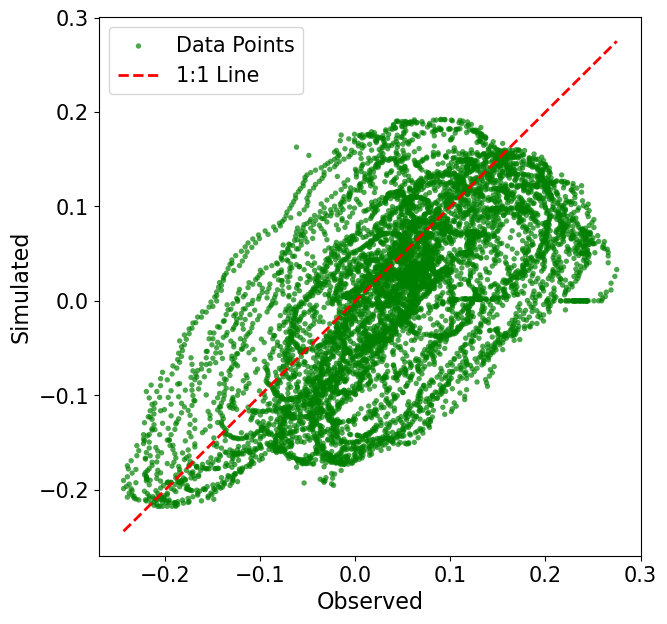

In [26]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Define paths to the observed and simulated dfs0 files
file1 = r"D:\Phd Research\Data\Water Level Data\Mike time series dfso\USS Lexington July 2022.dfs0"
file2 = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\Simulated_Matagorda v2.dfs0"

# Define the time range for filtering
start_time = datetime(2022, 7, 1, 17, 0, 0)
end_time = datetime(2022, 7, 31, 23, 54, 0)

# Read the dfs0 files
observed_dfs = mikeio.read(file1)
simulated_dfs = mikeio.read(file2)

# Extract data and time
observed_time = observed_dfs.time
simulated_time = simulated_dfs.time
observed_data = observed_dfs[0].to_numpy()
simulated_data = simulated_dfs[6].to_numpy()

# Apply time range filtering
observed_mask = (observed_time >= start_time) & (observed_time <= end_time)
simulated_mask = (simulated_time >= start_time) & (simulated_time <= end_time)

observed_time = observed_time[observed_mask]
observed_data = observed_data[observed_mask]
simulated_time = simulated_time[simulated_mask]
simulated_data = simulated_data[simulated_mask]

# Align data by interpolating if time lengths differ
if len(observed_time) != len(simulated_time):
    if len(observed_time) > len(simulated_time):
        # Interpolate simulated data to observed time
        simulated_data = np.interp(
            [t.timestamp() for t in observed_time], 
            [t.timestamp() for t in simulated_time], 
            simulated_data
        )
        time_common = observed_time
    else:
        # Interpolate observed data to simulated time
        observed_data = np.interp(
            [t.timestamp() for t in simulated_time], 
            [t.timestamp() for t in observed_time], 
            observed_data
        )
        time_common = simulated_time
else:
    time_common = observed_time  # No interpolation needed

# Calculate RMSE, R-squared, and NSE without sklearn
rmse = np.sqrt(np.mean((observed_data - simulated_data) ** 2))

# R-squared calculation
ss_res = np.sum((observed_data - simulated_data) ** 2)
ss_tot = np.sum((observed_data - np.mean(observed_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# NSE calculation
nse = 1 - (np.sum((observed_data - simulated_data) ** 2) / np.sum((observed_data - np.mean(observed_data)) ** 2))

print("Model Performance Metrics:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")
print(f"Nash-Sutcliffe Efficiency (NSE): {nse:.3f}")

# Plot observed vs simulated data
plt.figure(figsize=(10, 6))
plt.plot(time_common, observed_data, label="Observed", color="blue")
plt.plot(time_common, simulated_data, label="Simulated", color="orange")

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Observed vs Simulated Model Performance")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Scatter plot of observed vs simulated with a 1:1 line
# Scatter plot of observed vs simulated with a 1:1 line
plt.figure(figsize=(7, 7))

# Customize scatter plot with point size, shape, and color
plt.scatter(
    observed_data, 
    simulated_data, 
    s=15,              # Point size
    c="green",         # Color
    edgecolor="none", # Edge color for points
    alpha=0.7,         # Transparency
    marker="o",        # Point shape ('o' for circles, '^' for triangles, 's' for squares, etc.)
    label="Data Points"
)

# 1:1 line for reference
plt.plot(
    [min(observed_data), max(observed_data)], 
    [min(observed_data), max(observed_data)], 
    'r--', 
    linewidth=2,    # Line width
    label="1:1 Line"  # Label for legend
)

# Customize axis labels, title, and tick parameters
plt.xlabel("Observed", fontsize=16)  # Axis label size
plt.ylabel("Simulated", fontsize=16) # Axis label size


# Customize axis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Adding legend, grid, and display
plt.legend(fontsize=15)


# Adding labels, title, and limits
plt.xlabel("Observed")
plt.ylabel("Simulated")
# plt.title("Observed vs Simulated (1:1 Line)")
plt.grid(False)

# Show the scatter plot
plt.show()

Model Performance Metrics:
Root Mean Square Error (RMSE): 0.092
R-squared (R2): 0.157
Nash-Sutcliffe Efficiency (NSE): 0.157


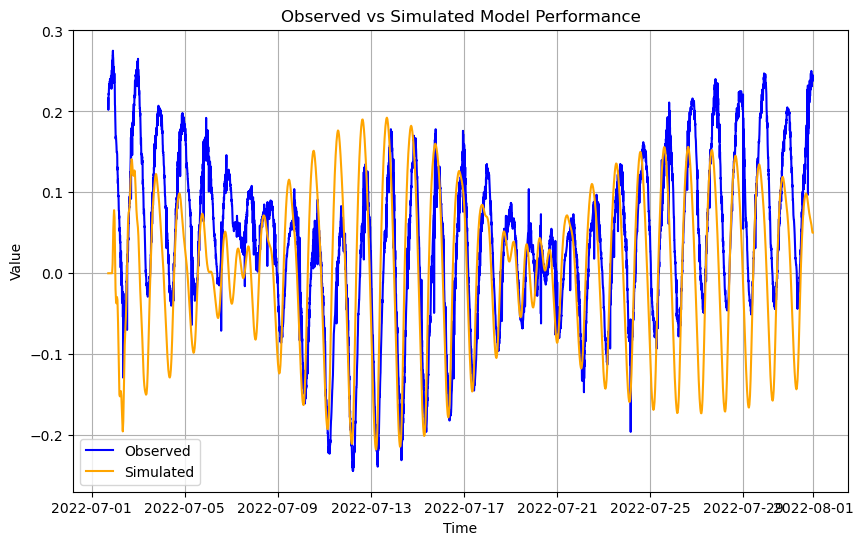

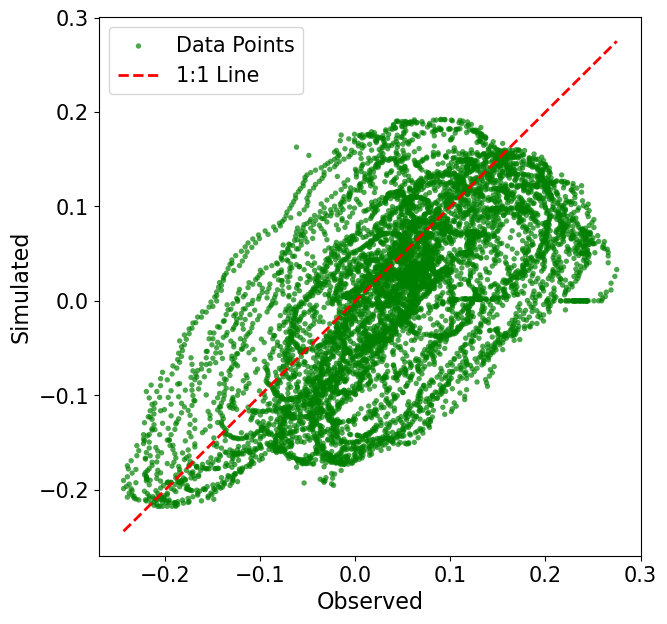

In [29]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Define paths to the observed and simulated dfs0 files
file1 = r"D:\Phd Research\Data\Water Level Data\Mike time series dfso\USS Lexington July 2022.dfs0"
file2 = r"D:\Phd Research\Prototype HD Model\Simulation\July_2022.m21fm - Result Files\Simulated_Matagorda v2.dfs0"

# Define the time range for filtering
start_time = datetime(2022, 7, 1, 17, 0, 0)
end_time = datetime(2022, 7, 31, 23, 54, 0)

# Read the dfs0 files
observed_dfs = mikeio.read(file1)
simulated_dfs = mikeio.read(file2)

# Extract data and time
observed_time = observed_dfs.time
simulated_time = simulated_dfs.time
observed_data = observed_dfs[0].to_numpy()
simulated_data = simulated_dfs[6].to_numpy()

# Apply time range filtering
observed_mask = (observed_time >= start_time) & (observed_time <= end_time)
simulated_mask = (simulated_time >= start_time) & (simulated_time <= end_time)

observed_time = observed_time[observed_mask]
observed_data = observed_data[observed_mask]
simulated_time = simulated_time[simulated_mask]
simulated_data = simulated_data[simulated_mask]

# Align data by interpolating if time lengths differ
if len(observed_time) != len(simulated_time):
    if len(observed_time) > len(simulated_time):
        # Interpolate simulated data to observed time
        simulated_data = np.interp(
            [t.timestamp() for t in observed_time], 
            [t.timestamp() for t in simulated_time], 
            simulated_data
        )
        time_common = observed_time
    else:
        # Interpolate observed data to simulated time
        observed_data = np.interp(
            [t.timestamp() for t in simulated_time], 
            [t.timestamp() for t in observed_time], 
            observed_data
        )
        time_common = simulated_time
else:
    time_common = observed_time  # No interpolation needed

# Calculate RMSE, R-squared, and NSE without sklearn
rmse = np.sqrt(np.mean((observed_data - simulated_data) ** 2))

# R-squared calculation
ss_res = np.sum((observed_data - simulated_data) ** 2)
ss_tot = np.sum((observed_data - np.mean(observed_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# NSE calculation
nse = 1 - (np.sum((observed_data - simulated_data) ** 2) / np.sum((observed_data - np.mean(observed_data)) ** 2))

print("Model Performance Metrics:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")
print(f"Nash-Sutcliffe Efficiency (NSE): {nse:.3f}")

# Plot observed vs simulated data
plt.figure(figsize=(10, 6))
plt.plot(time_common, observed_data, label="Observed", color="blue")
plt.plot(time_common, simulated_data, label="Simulated", color="orange")

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Observed vs Simulated Model Performance")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Scatter plot of observed vs simulated with a 1:1 line
# Scatter plot of observed vs simulated with a 1:1 line
plt.figure(figsize=(7, 7))

# Customize scatter plot with point size, shape, and color
plt.scatter(
    observed_data, 
    simulated_data, 
    s=15,              # Point size
    c="green",         # Color
    edgecolor="none", # Edge color for points
    alpha=0.7,         # Transparency
    marker="o",        # Point shape ('o' for circles, '^' for triangles, 's' for squares, etc.)
    label="Data Points"
)

# 1:1 line for reference
plt.plot(
    [min(observed_data), max(observed_data)], 
    [min(observed_data), max(observed_data)], 
    'r--', 
    linewidth=2,    # Line width
    label="1:1 Line"  # Label for legend
)

# Customize axis labels, title, and tick parameters
plt.xlabel("Observed", fontsize=16)  # Axis label size
plt.ylabel("Simulated", fontsize=16) # Axis label size


# Customize axis ticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Adding legend, grid, and display
plt.legend(fontsize=15)


# Adding labels, title, and limits
plt.xlabel("Observed")
plt.ylabel("Simulated")
# plt.title("Observed vs Simulated (1:1 Line)")
plt.grid(False)

# Show the scatter plot
plt.show()